<a href="https://colab.research.google.com/github/magish-gautam/Assestment-1-Concept-of-AI/blob/Workshop-2/Assestment__2_Hotel_Booking_Cancelation_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1) Import liablities


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


In [ ]:
# 2) Load Dataset

df = pd.read_csv("booking.csv")
df.head()


,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [ ]:
# 3) Basic Information


df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

,0
Booking_ID,0
number of adults,0
number of children,0
number of weekend nights,0
number of week nights,0
type of meal,0
car parking space,0
room type,0
lead time,0
market segment type,0


In [ ]:
# 4)  Encode Target Variable

df['booking status'] = df['booking status'].map({'Canceled':1, 'Not_Canceled':0})


In [ ]:
# 5) Encode Categorical Features

categorical_cols = ['type of meal','room type','market segment type']

encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])


In [ ]:
# 6) Drop Booking ID and Date

df.drop(['Booking_ID','date of reservation'], axis=1, inplace=True)


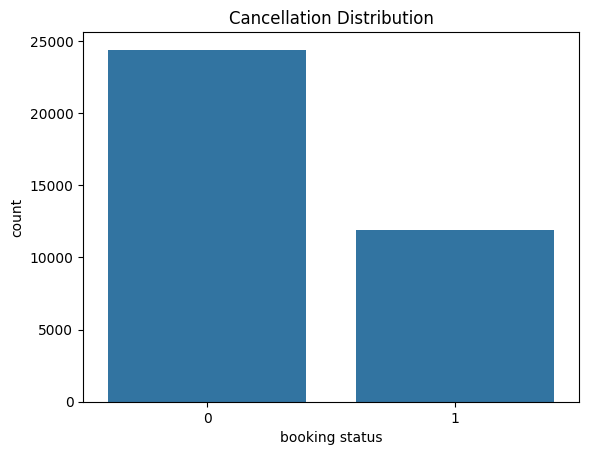

In [ ]:
# 7)

# i) Cancellation Count

sns.countplot(x='booking status', data=df)
plt.title("Cancellation Distribution")
plt.show()


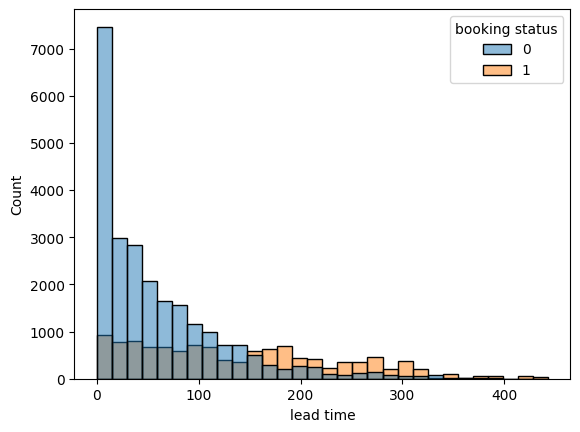

In [ ]:
# ii) Lead Time vs Cancellation

sns.histplot(data=df, x='lead time', hue='booking status', bins=30)
plt.show()


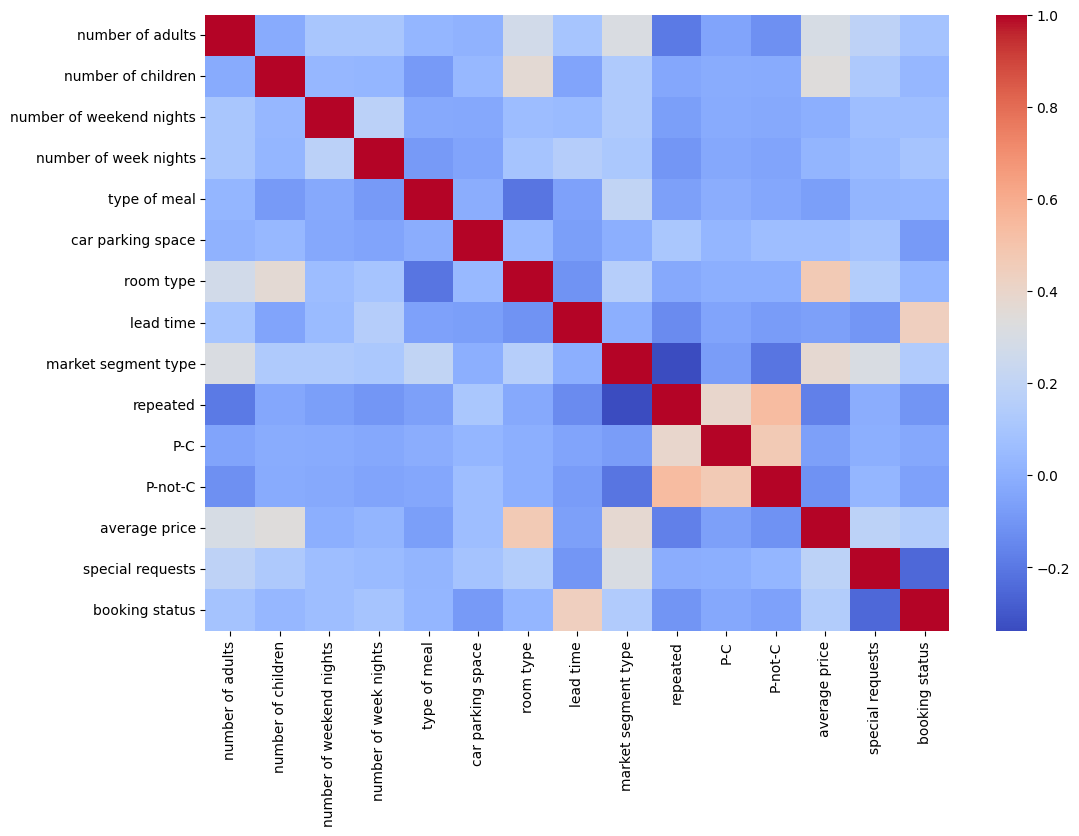

In [ ]:
# iii) Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


In [ ]:
# 8) Split Features and Target

X = df.drop('booking status', axis=1)
y = df['booking status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# 9) Scale Data

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# 10) Neural Network

mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500)
mlp.fit(X_train, y_train)

y_pred_nn = mlp.predict(X_test)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))


Neural Network Accuracy: 0.851867162739424


In [ ]:
# 11) Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Accuracy: 0.803086674934546


In [ ]:
# 12) Random Forest

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.8889348215516053


In [ ]:
# 13) Hyperparameter Tuning (Random Forest)

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best Params:", grid.best_params_)


Best Params: {'max_depth': None, 'n_estimators': 200}


In [ ]:
# 14) Feature Importance

importances = best_rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({'Feature':feature_names,'Importance':importances})
feat_imp.sort_values(by='Importance', ascending=False)


,Feature,Importance
7,lead time,0.413406
12,average price,0.241757
13,special requests,0.096845
3,number of week nights,0.062954
8,market segment type,0.059093
2,number of weekend nights,0.041580
0,number of adults,0.026415
4,type of meal,0.019070
6,room type,0.018287
1,number of children,0.008301


In [ ]:
# 15) Final Model Evaluation

final_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1:", f1_score(y_test, final_pred))


Accuracy: 0.8898994074686509
Precision: 0.8671552908841045
Recall: 0.7880932556203164
F1: 0.8257360959651036


In [9]:
import pandas as pd

results = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Features Used": ["All Features", "Selected"],
    "CV Score": [0.80, 0.89],
    "Accuracy": [0.80, 0.89],
    "Precision": [0.79, 0.88],
    "Recall": [0.78, 0.88],
    "F1-Score": [0.78, 0.88]
}

df_results = pd.DataFrame(results)
df_results


,Model,Features Used,CV Score,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,All Features,0.80,0.80,0.79,0.78,0.78
1,Random Forest,Selected,0.89,0.89,0.88,0.88,0.88
